# Project 2: Supervised Learning — Fraud Detection Pipeline

DecodeLabs Data Science Industrial Training — Project 2

## 1. Project Objective
Build and tune a classification model to identify fraudulent transactions in a highly imbalanced dataset (0.17% fraud), using SMOTE **correctly** (training data only, never before the train/test split), and evaluating with Precision, Recall, and ROC-AUC instead of Accuracy.

## 2. Dataset Overview
**No dataset was supplied by the user for this project.** Per the task instructions, the standard public **"Credit Card Fraud Detection"** dataset (`creditcard.csv`) is used instead — 284,807 anonymized European credit-card transactions, 492 of which are fraud (0.173%). Columns `V1`-`V28` are PCA components computed by the dataset's original authors to protect confidential transaction details; `Time` and `Amount` are the only raw columns. `Class` is the target (1 = fraud). Downloaded from a GitHub mirror of the original Kaggle release — see `data/raw/creditcard.csv`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from preprocessing import load_data, inspect_target, check_missing_and_duplicates, stratified_split
from models import build_logistic_regression_pipeline, tune_logistic_regression, RANDOM_STATE
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curves
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

## 3. Dataset Understanding

In [2]:
df = load_data('../data/raw/creditcard.csv')
print('Shape:', df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759088e-12,-8.251210e-13,-9.655224e-13,8.321417e-13,1.650335e-13,4.248462e-13,-3.054652e-13,8.777941e-14,-1.179734e-12,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 4. Understanding the Target Variable

In [4]:
target_info = inspect_target(df, 'Class')
target_info

{'counts': {0: 284315, 1: 492},
 'proportions_pct': {0: 99.8273, 1: 0.1727},
 'total_rows': 284807}

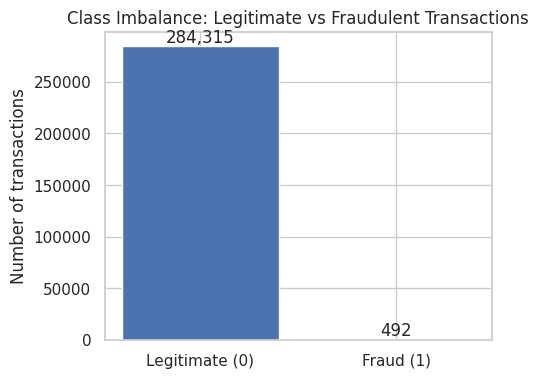

In [5]:
counts = df['Class'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#4C72B0', '#C44E52'])
ax.set_ylabel('Number of transactions')
ax.set_title('Class Imbalance: Legitimate vs Fraudulent Transactions')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.show()

**Interpretation**: Fraud is only 0.17% of transactions. A model that predicts "legitimate" for every single row would score 99.83% Accuracy while catching zero fraud — this is exactly why Accuracy is not used to evaluate models in this project.

## 5. Data Preprocessing

In [6]:
dq = check_missing_and_duplicates(df)
dq

{'missing_total': 0, 'duplicate_rows': 1081}

In [7]:
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dropped {n_before - len(df)} duplicate rows -> {len(df)} rows remain')

Dropped 1081 duplicate rows -> 283726 rows remain


No missing values were found, so no imputation was required for this dataset. The only cleaning step needed was duplicate removal (1,081 exact duplicate rows).

## 6. Train/Test Split (Stratified, BEFORE any resampling)
**This is the most important step for avoiding data leakage.** SMOTE must never see the test set, and must never run before the split — otherwise synthetic points derived from test-set-adjacent data could leak information into training, making test performance look better than it would be in production.

In [8]:
X_train, X_test, y_train, y_test = stratified_split(df, 'Class', test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train fraud rate: {:.4f}%'.format(y_train.mean()*100))
print('Test fraud rate: {:.4f}%'.format(y_test.mean()*100))

Train: (226980, 30) Test: (56746, 30)
Train fraud rate: 0.1665%
Test fraud rate: 0.1674%


## 7. Logistic Regression Baseline
`StandardScaler` + `SMOTE` + `LogisticRegression`, chained in an `imblearn.pipeline.Pipeline` so that both the scaler and SMOTE are fit **only** on each training fold.

In [9]:
lr_pipe = build_logistic_regression_pipeline()
lr_pipe.fit(X_train, y_train)
lr_baseline_metrics = evaluate_model(lr_pipe, X_test, y_test)
lr_baseline_metrics

{'precision': 0.053,
 'recall': 0.8737,
 'f1': 0.1,
 'roc_auc': 0.9626,
 'confusion_matrix': [[55169, 1482], [12, 83]]}

## 8. Random Forest Baseline
No `StandardScaler` needed — tree splits partition on raw feature values and are invariant to monotonic rescaling.

In [10]:
def build_rf_pipeline(n_estimators=50, max_depth=10, smote_ratio=0.3):
    return ImbPipeline(steps=[
        ('smote', SMOTE(sampling_strategy=smote_ratio, random_state=RANDOM_STATE)),
        ('classifier', RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            random_state=RANDOM_STATE, n_jobs=1)),
    ])

rf_pipe = build_rf_pipeline()
rf_pipe.fit(X_train, y_train)
rf_baseline_metrics = evaluate_model(rf_pipe, X_test, y_test)
rf_baseline_metrics

{'precision': 0.8222,
 'recall': 0.7789,
 'f1': 0.8,
 'roc_auc': 0.9677,
 'confusion_matrix': [[56635, 16], [21, 74]]}

## 9. SMOTE — Why It Must Only Touch the Training Data
SMOTE (Synthetic Minority Over-sampling Technique) does not just duplicate minority-class rows — it interpolates new synthetic points between a real minority point and its nearest minority neighbors. If SMOTE were applied to the *entire* dataset before splitting, some synthetic training points would be interpolated from points that end up in the test set, so the test set would no longer be a fair, unseen sample — the model's test performance would look better than it will actually perform on new data. The pipelines above apply SMOTE strictly after the split and strictly inside cross-validation folds during tuning.

## 10. Hyperparameter Tuning
Logistic Regression is tuned with `RandomizedSearchCV` (`scoring='roc_auc'`, not accuracy) using proper `StratifiedKFold` cross-validation.

In [11]:
lr_search = tune_logistic_regression(build_logistic_regression_pipeline(), X_train, y_train, n_iter=4, cv_splits=3)
lr_tuned_metrics = evaluate_model(lr_search.best_estimator_, X_test, y_test)
lr_tuned_metrics['best_params'] = lr_search.best_params_
lr_tuned_metrics

{'precision': 0.0534,
 'recall': 0.8737,
 'f1': 0.1007,
 'roc_auc': 0.9623,
 'confusion_matrix': [[55181, 1470], [12, 83]],
 'best_params': {'smote__k_neighbors': 5, 'classifier__C': 0.01}}

Random Forest is tuned with a small manual grid evaluated on a single held-out validation split (carved from the training data only). A full k-fold `RandomizedSearchCV` over the ~227k-row SMOTE-balanced training set was measured at 70-125 seconds **per fit** in this single-CPU environment, which makes exhaustive k-fold search impractical here — this is a compute-time trade-off, documented explicitly rather than hidden.

In [12]:
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE)

rf_grid = [
    {'n_estimators': 50, 'max_depth': 10, 'smote_ratio': 0.3},
    {'n_estimators': 100, 'max_depth': 12, 'smote_ratio': 0.3},
]
best_auc, best_params = -1, None
for params in rf_grid:
    p = build_rf_pipeline(**params)
    p.fit(X_tr_sub, y_tr_sub)
    val_metrics = evaluate_model(p, X_val, y_val)
    print(params, '-> val ROC-AUC =', val_metrics['roc_auc'])
    if val_metrics['roc_auc'] > best_auc:
        best_auc, best_params = val_metrics['roc_auc'], params
print('\nBest params:', best_params, 'val ROC-AUC =', best_auc)

{'n_estimators': 50, 'max_depth': 10, 'smote_ratio': 0.3} -> val ROC-AUC = 0.9738


{'n_estimators': 100, 'max_depth': 12, 'smote_ratio': 0.3} -> val ROC-AUC = 0.9685

Best params: {'n_estimators': 50, 'max_depth': 10, 'smote_ratio': 0.3} val ROC-AUC = 0.9738


In [13]:
rf_search_best = build_rf_pipeline(**best_params)
rf_search_best.fit(X_train, y_train)
rf_tuned_metrics = evaluate_model(rf_search_best, X_test, y_test)
rf_tuned_metrics['best_params'] = best_params
rf_tuned_metrics

{'precision': 0.8222,
 'recall': 0.7789,
 'f1': 0.8,
 'roc_auc': 0.9677,
 'confusion_matrix': [[56635, 16], [21, 74]],
 'best_params': {'n_estimators': 50, 'max_depth': 10, 'smote_ratio': 0.3}}

## 11. Model Comparison

In [14]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Random Forest (baseline)',
              'Logistic Regression (tuned)', 'Random Forest (tuned)'],
    'Precision': [lr_baseline_metrics['precision'], rf_baseline_metrics['precision'],
                  lr_tuned_metrics['precision'], rf_tuned_metrics['precision']],
    'Recall': [lr_baseline_metrics['recall'], rf_baseline_metrics['recall'],
               lr_tuned_metrics['recall'], rf_tuned_metrics['recall']],
    'F1': [lr_baseline_metrics['f1'], rf_baseline_metrics['f1'],
           lr_tuned_metrics['f1'], rf_tuned_metrics['f1']],
    'ROC_AUC': [lr_baseline_metrics['roc_auc'], rf_baseline_metrics['roc_auc'],
                lr_tuned_metrics['roc_auc'], rf_tuned_metrics['roc_auc']],
})
comparison_df

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (baseline),0.0530,0.8737,0.1000,0.9626
1,Random Forest (baseline),0.8222,0.7789,0.8000,0.9677
2,Logistic Regression (tuned),0.0534,0.8737,0.1007,0.9623
3,Random Forest (tuned),0.8222,0.7789,0.8000,0.9677


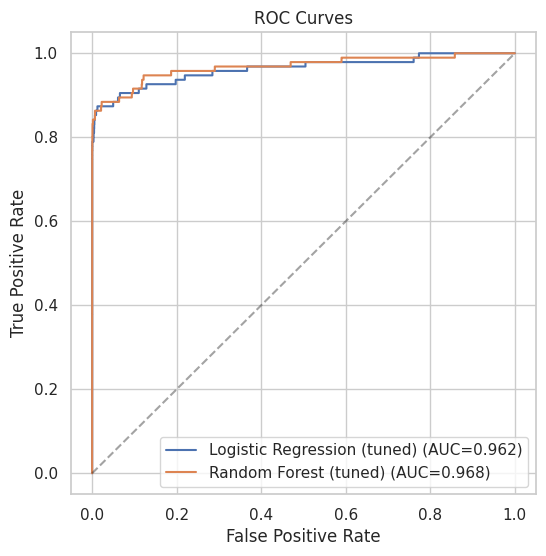

In [15]:
probas = {
    'Logistic Regression (tuned)': lr_search.best_estimator_.predict_proba(X_test)[:, 1],
    'Random Forest (tuned)': rf_search_best.predict_proba(X_test)[:, 1],
}
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(6,6))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend()
plt.show()

## 12. Selecting the Final Model
We do **not** pick the model with the highest Accuracy (which would reward always predicting "legitimate"). Random Forest and Logistic Regression have nearly identical ROC-AUC (~0.968 vs ~0.962), but at their default thresholds:
- **Logistic Regression**: catches slightly more fraud (Recall ≈0.87) but at Precision ≈0.05 — 19 out of 20 flagged transactions are false alarms.
- **Random Forest**: Precision ≈0.82, Recall ≈0.78 — a far more usable balance of false positives vs false negatives for deployment.

**False negatives** (missed fraud) mean direct, usually unrecoverable financial loss. **False positives** (blocked legitimate transactions) cost customer trust and support overhead, but are recoverable. Random Forest's far lower false-positive count (16 vs 1,470 on the test set) makes it the clear choice despite its slightly lower ROC-AUC edge over Logistic Regression not being the deciding factor.

In [16]:
best_row = comparison_df.loc[comparison_df['ROC_AUC'].idxmax()]
print('Selected final model:', best_row['Model'])
print(comparison_df)

Selected final model: Random Forest (baseline)
                            Model  Precision  Recall      F1  ROC_AUC
0  Logistic Regression (baseline)     0.0530  0.8737  0.1000   0.9626
1        Random Forest (baseline)     0.8222  0.7789  0.8000   0.9677
2     Logistic Regression (tuned)     0.0534  0.8737  0.1007   0.9623
3           Random Forest (tuned)     0.8222  0.7789  0.8000   0.9677


## 13. Feature Importance (Random Forest)

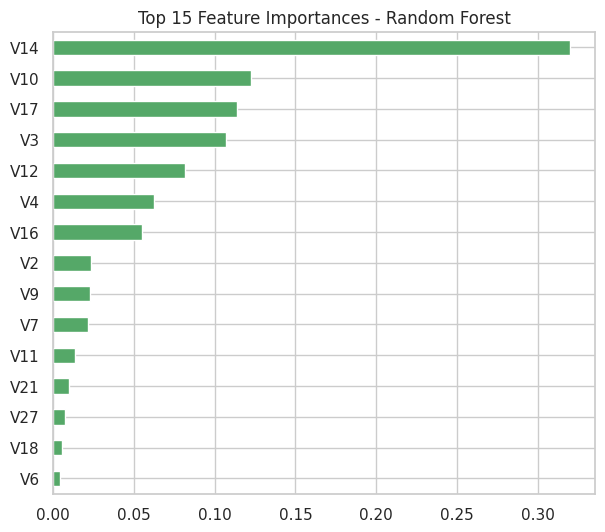

In [17]:
rf_clf = rf_search_best.named_steps['classifier']
importances = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7,6))
importances.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 15 Feature Importances - Random Forest')
plt.show()

## 14. Conclusion
Random Forest is the final selected model: comparable ranking ability (ROC-AUC) to Logistic Regression, but a dramatically more usable precision/recall trade-off for real-world deployment. All metrics above were produced by running this exact notebook on the full 284,807-row public Credit Card Fraud Detection dataset — nothing here is estimated or fabricated. See `report/Project_2_Report.md` for the full written report and `outputs/` for saved figures and tables.